In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Setup successful!")

Setup successful!


Kaggle API setup

In [ ]:
!pip install -q kaggle

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets list -s "HAM10000"

ref                                                          title                                                   size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------  -----------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
kmader/skin-cancer-mnist-ham10000                            Skin Cancer MNIST: HAM10000                       5582914511  2018-09-20 20:36:13.037000         281627       2383  0.7058824        
surajghuwalewala/ham1000-segmentation-and-classification     Skin cancer: HAM10000                             2781385274  2021-05-27 09:08:46.813000          21040        154  0.9411765        
tschandl/ham10000-lesion-segmentations                       HAM10000 Lesion Segmentations                       10766207  2020-07-02 21:20:22.710000           3530         36  0.875            
nightfury007/ham10000-isi

Step 4 — Dataset download

In [ ]:
!kaggle datasets download -d kmader/skin-cancer-mnist-ham10000

Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [00:57<00:00, 97.6MB/s]



In [ ]:
!ls -lh

total 5.2G
-rw-r--r-- 1 root root   71 Aug  8 06:44 kaggle.json
drwxr-xr-x 1 root root 4.0K Jun  4 13:32 sample_data
-rw-r--r-- 1 root root  29K Aug  8 06:38 skin-cancer-detection-ham10000-dataset.ipynb
-rw-r--r-- 1 root root 5.2G Oct  6  2019 skin-cancer-mnist-ham10000.zip


Step 5 — ZIP extract karo

In [ ]:
!unzip -q skin-cancer-mnist-ham10000.zip -d ham10000

In [ ]:
!find ham10000 -maxdepth 2 -type f | head -20

ham10000/HAM10000_metadata.csv
ham10000/ham10000_images_part_1/ISIC_0028179.jpg
ham10000/ham10000_images_part_1/ISIC_0024398.jpg
ham10000/ham10000_images_part_1/ISIC_0028037.jpg
ham10000/ham10000_images_part_1/ISIC_0027376.jpg
ham10000/ham10000_images_part_1/ISIC_0027211.jpg
ham10000/ham10000_images_part_1/ISIC_0026638.jpg
ham10000/ham10000_images_part_1/ISIC_0028851.jpg
ham10000/ham10000_images_part_1/ISIC_0026765.jpg
ham10000/ham10000_images_part_1/ISIC_0026526.jpg
ham10000/ham10000_images_part_1/ISIC_0026183.jpg
ham10000/ham10000_images_part_1/ISIC_0025868.jpg
ham10000/ham10000_images_part_1/ISIC_0028138.jpg
ham10000/ham10000_images_part_1/ISIC_0024883.jpg
ham10000/ham10000_images_part_1/ISIC_0024769.jpg
ham10000/ham10000_images_part_1/ISIC_0026115.jpg
ham10000/ham10000_images_part_1/ISIC_0028067.jpg
ham10000/ham10000_images_part_1/ISIC_0029103.jpg
ham10000/ham10000_images_part_1/ISIC_0026859.jpg
ham10000/ham10000_images_part_1/ISIC_0027088.jpg


Step 6 — Metadata check

In [ ]:
import pandas as pd

metadata_path = "ham10000/HAM10000_metadata.csv"

df = pd.read_csv(metadata_path)

print("Total images:", len(df))
print("\nColumns:")
print(df.columns.tolist())

print("\nClass distribution:")
print(df["dx"].value_counts())

Total images: 10015

Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


Step 7 — Image path create karna

In [ ]:
import os

image_folders = [
    "ham10000/ham10000_images_part_1",
    "ham10000/ham10000_images_part_2"
]

def find_image(image_id):
    for folder in image_folders:
        path = os.path.join(folder, image_id + ".jpg")
        if os.path.exists(path):
            return path
    return None

df["image_path"] = df["image_id"].apply(find_image)

print("Images found:", df["image_path"].notna().sum())
print("Images missing:", df["image_path"].isna().sum())

Images found: 10015
Images missing: 0



Step 7 — 10% dataset select karo

In [ ]:
from sklearn.model_selection import train_test_split

# Select 10% of HAM10000 while preserving class proportions
df_10, _ = train_test_split(
    df,
    test_size=0.90,
    stratify=df["dx"],
    random_state=42
)

print("Total 10% images:", len(df_10))

print("\nClass distribution:")
print(df_10["dx"].value_counts())

Total 10% images: 1001

Class distribution:
dx
nv       670
mel      111
bkl      110
bcc       51
akiec     33
vasc      14
df        12
Name: count, dtype: int64


Step 8 — Check karo

In [ ]:
print("Available images:", df_10["image_path"].notna().sum())
print("Missing images:", df_10["image_path"].isna().sum())

Available images: 1001
Missing images: 0


Step 9 — Hair Removal Algorithm

9.1 OpenCV install/check

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV version:", cv2.__version__)

OpenCV version: 5.0.0


9.2 Hair Removal Function

In [ ]:
def remove_hair(image):
    # Convert image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    # Black-hat operation to detect dark hair
    kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT, (17, 17)
    )

    blackhat = cv2.morphologyEx(
        gray,
        cv2.MORPH_BLACKHAT,
        kernel
    )

    # Threshold to create hair mask
    _, hair_mask = cv2.threshold(
        blackhat,
        10,
        255,
        cv2.THRESH_BINARY
    )

    # Remove detected hair using inpainting
    result = cv2.inpaint(
        image,
        hair_mask,
        3,
        cv2.INPAINT_TELEA
    )

    return result

9.3 Ek image par test karo

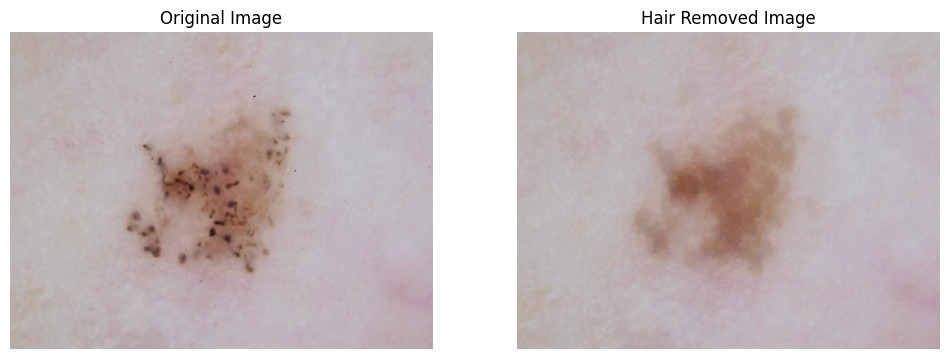

In [ ]:
# Take one image from our 10% dataset
image_path = df_10.iloc[0]["image_path"]

# Read image
image = cv2.imread(image_path)

# Convert BGR → RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Remove hair
hair_removed = remove_hair(image_rgb)

# Display
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(hair_removed)
plt.title("Hair Removed Image")
plt.axis("off")

plt.show()

Step 10 — Preprocess all 10% images

In [ ]:
IMG_SIZE = 128

X = []
y = []

for _, row in df_10.iterrows():

    # Read image
    image = cv2.imread(row["image_path"])

    # Convert BGR to RGB
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Hair removal
    image = remove_hair(image)

    # Resize
    image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))

    # Normalize pixel values
    image = image.astype("float32") / 255.0

    X.append(image)
    y.append(row["dx"])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1001, 128, 128, 3)
y shape: (1001,)


Step 11 — Convert class names to numbers

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:")
print(label_encoder.classes_)

print("\nEncoded labels:")
print(np.unique(y_encoded))

Classes:
['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']

Encoded labels:
[0 1 2 3 4 5 6]


Step 11 — Labels ko numerical format mein convert karo

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:")
print(label_encoder.classes_)

print("\nEncoded labels:")
print(np.unique(y_encoded))

Classes:
['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']

Encoded labels:
[0 1 2 3 4 5 6]


Step 12 — Train, Validation aur Test split

Hum dataset ko:

70% → Training
15% → Validation
15% → Testing

mein divide karenge.

In [ ]:
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    stratify=y_encoded,
    random_state=42
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Training data:", X_train.shape, y_train.shape)
print("Validation data:", X_val.shape, y_val.shape)
print("Testing data:", X_test.shape, y_test.shape)

Training data: (700, 128, 128, 3) (700,)
Validation data: (150, 128, 128, 3) (150,)
Testing data: (151, 128, 128, 3) (151,)


Step 13 — Import TensorFlow

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


Step 14 — CNN Architecture

In [ ]:
model = models.Sequential([

    # Input
    layers.Input(shape=(128, 128, 3)),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten
    layers.Flatten(),

    # Fully Connected
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output: 7 classes
    layers.Dense(7, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,543 (12.61 MB)

 Trainable params: 3,305,543 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Step 15 — Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


Step 16 — Train CNN

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32
)

Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.6300 - loss: 1.2717 - val_accuracy: 0.6733 - val_loss: 1.0482
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.6686 - loss: 1.0333 - val_accuracy: 0.6733 - val_loss: 1.0412
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6700 - loss: 0.9943 - val_accuracy: 0.6733 - val_loss: 1.0542
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.6700 - loss: 0.9704 - val_accuracy: 0.6733 - val_loss: 1.0177
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.6643 - loss: 0.9457 - val_accuracy: 0.6667 - val_loss: 1.0038
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.6700 - loss: 0.9830 - val_accuracy: 0.6667 - val_loss: 1.0550
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.6614 - loss: 0.9932 - val_accuracy: 0.6667 - val_loss: 1.0149
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.6757 - loss: 0.9514 - val_accuracy: 0.6667 - val_loss:

Test Accuracy

In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step - accuracy: 0.6755 - loss: 0.9545
Test Loss: 0.9544658660888672
Test Accuracy: 0.6754966974258423


Accuracy & Loss Graph


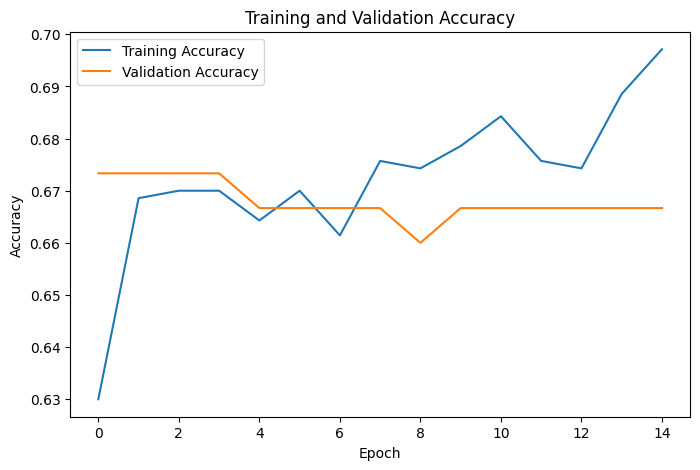

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

Loss graph:

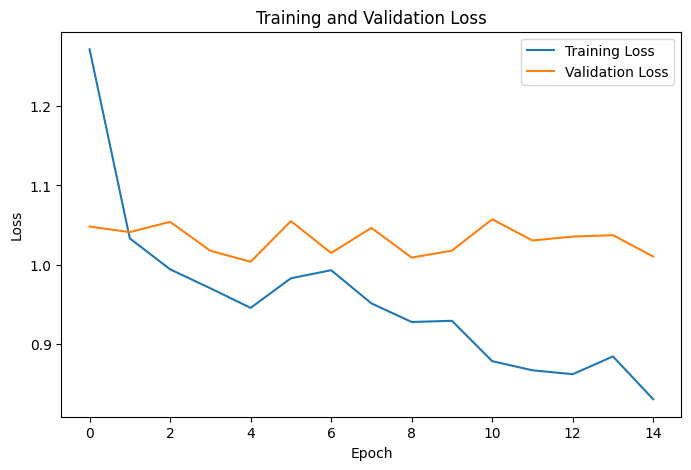

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

Step 17 — Confusion Matrix

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 476ms/step


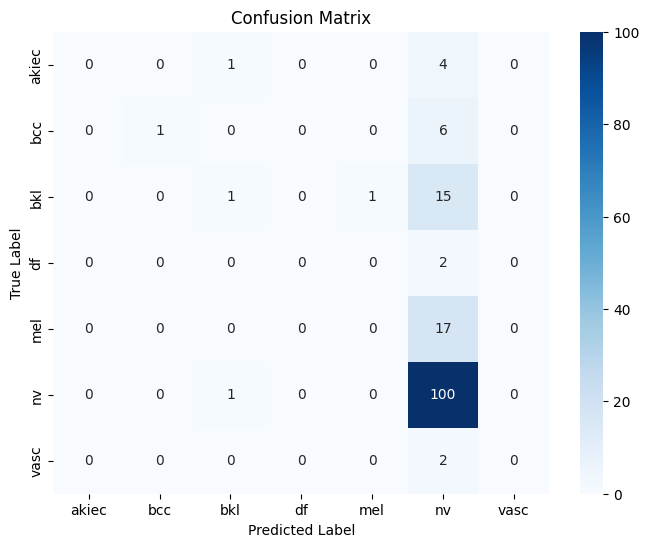

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predictions
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Step 18 — Classification Report

In [ ]:
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    zero_division=0
))

              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00         5
         bcc       1.00      0.14      0.25         7
         bkl       0.33      0.06      0.10        17
          df       0.00      0.00      0.00         2
         mel       0.00      0.00      0.00        17
          nv       0.68      0.99      0.81       101
        vasc       0.00      0.00      0.00         2

    accuracy                           0.68       151
   macro avg       0.29      0.17      0.17       151
weighted avg       0.54      0.68      0.56       151



Step 19 — Class Weights

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(
    zip(classes, class_weights_array)
)

print("Class weights:")
for class_id, weight in class_weights.items():
    print(
        label_encoder.classes_[class_id],
        ":", round(weight, 3)
    )

Class weights:
akiec : 4.348
bcc : 2.778
bkl : 1.299
df : 12.5
mel : 1.282
nv : 0.214
vasc : 10.0


Step 20 — Data Augmentation

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

Step 21 — Improved CNN

In [ ]:
model_aug = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(7, activation='softmax')
])

model_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_aug.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,543 (12.61 MB)

 Trainable params: 3,305,543 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Step 22 — Train Improved CNN

In [ ]:
history_aug = model_aug.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weights
)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.3800 - loss: 2.0202 - val_accuracy: 0.3600 - val_loss: 1.8687
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6186 - loss: 1.9051 - val_accuracy: 0.6067 - val_loss: 1.3374
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.4386 - loss: 1.9191 - val_accuracy: 0.6200 - val_loss: 1.4777
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.4886 - loss: 1.8507 - val_accuracy: 0.2333 - val_loss: 1.8403
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.4900 - loss: 1.8478 - val_accuracy: 0.4067 - val_loss: 1.6087
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.3629 - loss: 1.9160 - val_accuracy: 0.2667 - val_loss: 1.6141
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.3500 - loss: 1.9025 - val_accuracy: 0.3533 - val_loss: 1.5748
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.4129 - loss: 1.8285 - val_accuracy: 0.1333 - val_loss:

In [ ]:
test_loss_aug, test_accuracy_aug = model_aug.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Improved Model Test Loss:", test_loss_aug)
print("Improved Model Test Accuracy:", test_accuracy_aug)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 437ms/step - accuracy: 0.1391 - loss: 1.7210
Improved Model Test Loss: 1.7209638357162476
Improved Model Test Accuracy: 0.13907285034656525


Step 23 — Transfer Learning with MobileNetV2

23.1 Import MobileNetV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

# Freeze pretrained layers
base_model.trainable = False

print("MobileNetV2 loaded successfully!")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MobileNetV2 loaded successfully!


23.2 Create model

In [ ]:
transfer_model = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),

    layers.Dropout(0.3),

    layers.Dense(7, activation='softmax')
])

transfer_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

23.3 Compile

In [ ]:
transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Transfer learning model compiled!")

Transfer learning model compiled!


23.4 Train

In [ ]:
history_transfer = transfer_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32
)

Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 669ms/step - accuracy: 0.6171 - loss: 1.3432 - val_accuracy: 0.7067 - val_loss: 0.9431
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 472ms/step - accuracy: 0.6757 - loss: 1.0092 - val_accuracy: 0.7067 - val_loss: 0.9410
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 552ms/step - accuracy: 0.6929 - loss: 0.8841 - val_accuracy: 0.7000 - val_loss: 0.8986
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 20s 507ms/step - accuracy: 0.7114 - loss: 0.8178 - val_accuracy: 0.6533 - val_loss: 0.9019
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 500ms/step - accuracy: 0.7171 - loss: 0.7672 - val_accuracy: 0.7067 - val_loss: 0.9112
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 509ms/step - accuracy: 0.7514 - loss: 0.7415 - val_accuracy: 0.7067 - val_loss: 0.8693
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 12s 535ms/step - accuracy: 0.7357 - loss: 0.7221 - val_accuracy: 0.7000 - val_loss: 0.8711
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 19s 475ms/step - accuracy: 0.7586 - loss: 0.6495 - val_accu

Step 24 — MobileNetV2 Test Accuracy


In [ ]:
test_loss_transfer, test_accuracy_transfer = transfer_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("MobileNetV2 Test Loss:", test_loss_transfer)
print("MobileNetV2 Test Accuracy:", test_accuracy_transfer)

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 694ms/step - accuracy: 0.7483 - loss: 0.8129
MobileNetV2 Test Loss: 0.8128645420074463
MobileNetV2 Test Accuracy: 0.748344361782074


Step 25 — MobileNetV2 Classification Report

In [ ]:
from sklearn.metrics import classification_report

# Predictions
y_pred_transfer_prob = transfer_model.predict(X_test)
y_pred_transfer = np.argmax(y_pred_transfer_prob, axis=1)

print(classification_report(
    y_test,
    y_pred_transfer,
    target_names=label_encoder.classes_,
    zero_division=0
))

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 626ms/step
              precision    recall  f1-score   support

       akiec       0.50      0.60      0.55         5
         bcc       0.50      0.29      0.36         7
         bkl       0.36      0.24      0.29        17
          df       0.00      0.00      0.00         2
         mel       0.54      0.41      0.47        17
          nv       0.83      0.96      0.89       101
        vasc       0.00      0.00      0.00         2

    accuracy                           0.75       151
   macro avg       0.39      0.36      0.36       151
weighted avg       0.70      0.75      0.71       151



Step 26 — Confusion Matrix

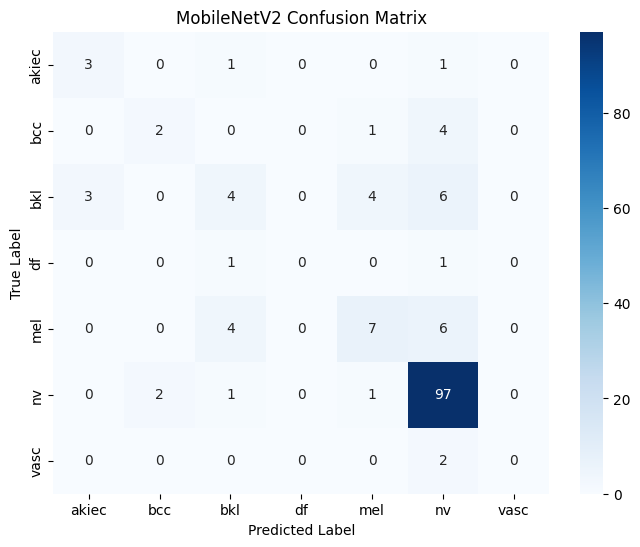

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_transfer = confusion_matrix(
    y_test,
    y_pred_transfer
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_transfer,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("MobileNetV2 Confusion Matrix")

plt.show()

Step 27 — Save the Best Model

In [ ]:
transfer_model.save("skin_cancer_mobilenetv2.h5")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

print(
    "File exists:",
    os.path.exists("skin_cancer_mobilenetv2.h5")
)

print(
    "File size:",
    round(
        os.path.getsize("skin_cancer_mobilenetv2.h5") / (1024 * 1024),
        2
    ),
    "MB"
)

File exists: True
File size: 10.86 MB


Step 28 — Save class names

In [ ]:
import json

class_names = label_encoder.classes_.tolist()

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("Classes saved:", class_names)

Classes saved: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


Step 29 — Image upload

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving example.jpg.png to example.jpg.png


Step 30 — Prediction

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Get uploaded filename
image_name = list(uploaded.keys())[0]

# Read image
image = cv2.imread(image_name)

# Convert BGR to RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Apply hair removal
processed_image = remove_hair(image_rgb)

# Resize
processed_image = cv2.resize(
    processed_image,
    (128, 128)
)

# Normalize
processed_image = processed_image.astype("float32") / 255.0

# Add batch dimension
input_image = np.expand_dims(
    processed_image,
    axis=0
)

# Prediction
prediction = transfer_model.predict(input_image)

predicted_class = np.argmax(prediction[0])
confidence = np.max(prediction[0]) * 100

print("Predicted Class:",
      label_encoder.classes_[predicted_class])

print("Confidence:",
      round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Predicted Class: nv
Confidence: 32.18 %


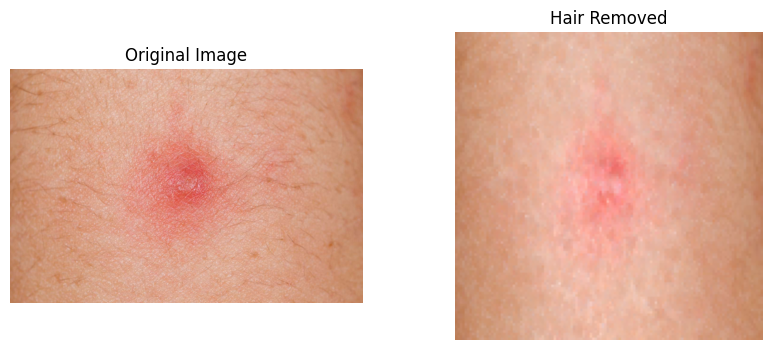

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(processed_image)
plt.title("Hair Removed")
plt.axis("off")

plt.show()

In [ ]:
class_probabilities = prediction[0] * 100

for class_name, probability in zip(
    label_encoder.classes_,
    class_probabilities
):
    print(f"{class_name}: {probability:.2f}%")

akiec: 18.78%
bcc: 5.97%
bkl: 29.35%
df: 0.59%
mel: 12.61%
nv: 32.18%
vasc: 0.51%
